In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [90]:
import pandas as pd
column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]
df = pd.read_csv(
    "banknote_authentication.csv",
    header=None,
    names=column_names
)

In [91]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [92]:
df.shape

(1372, 5)

In [93]:
df.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class'], dtype='object')

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [95]:
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [96]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


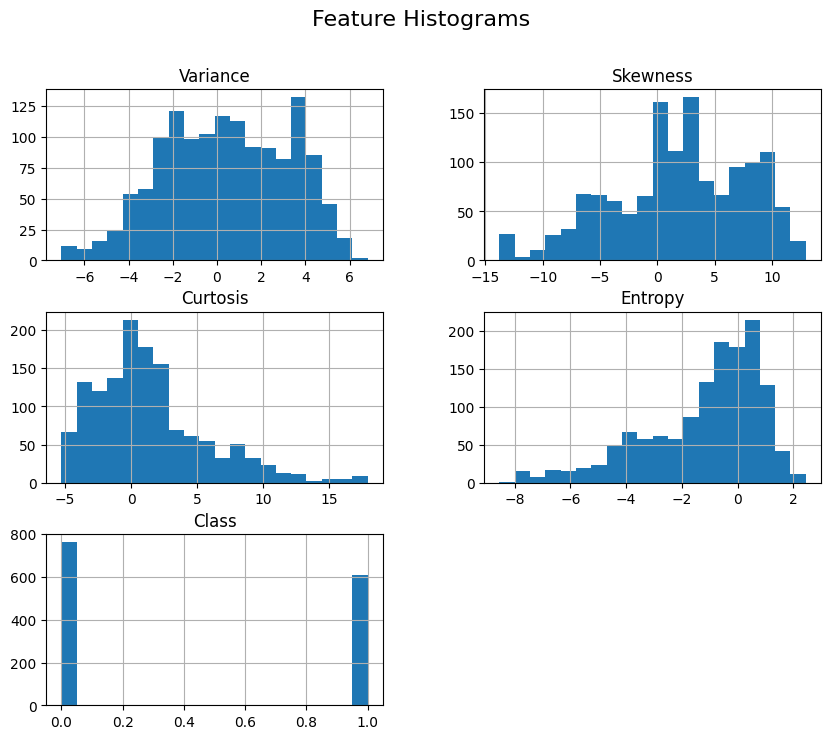

In [97]:
import matplotlib.pyplot as plt
df.hist(figsize=(10, 8), bins=20)
plt.suptitle("Feature Histograms", fontsize=16)
plt.show()

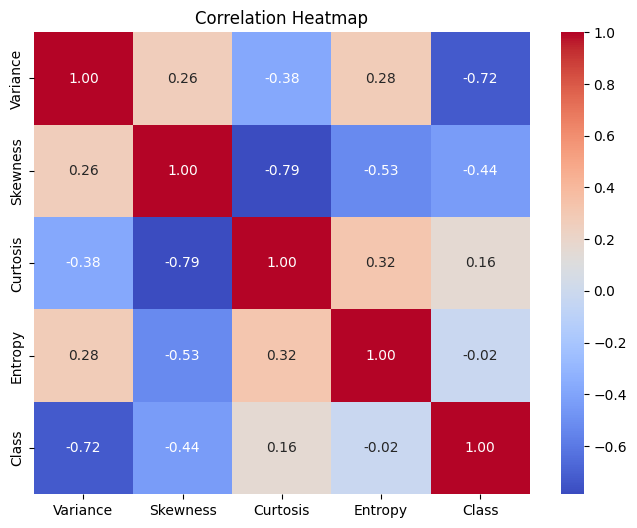

In [98]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

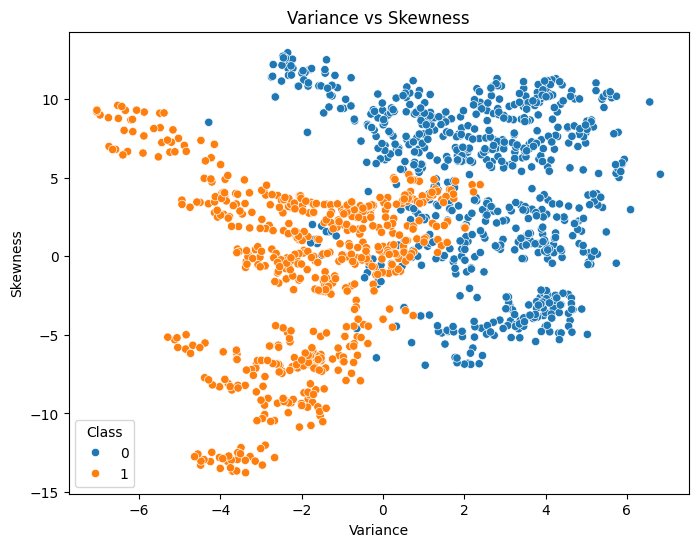

In [99]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class"
)
plt.title("Variance vs Skewness")
plt.show()

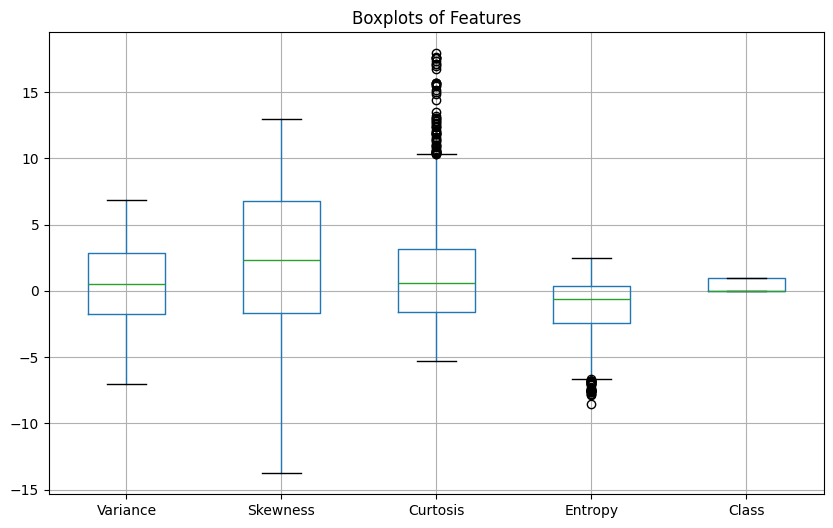

In [100]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.title("Boxplots of Features")
plt.show()

In [101]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [102]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1372, 4)
Target Shape: (1372,)


In [103]:
from sklearn.preprocessing import StandardScaler

In [104]:
scaler = StandardScaler()

In [105]:
X_scaled = scaler.fit_transform(X)

In [106]:
print(X_scaled[:5])

[[ 1.12180565  1.14945512 -0.97597007  0.35456135]
 [ 1.44706568  1.06445293 -0.89503626 -0.12876744]
 [ 1.20780971 -0.77735215  0.12221838  0.61807317]
 [ 1.06374236  1.29547754 -1.25539712 -1.14402883]
 [-0.03677175 -1.0870383   0.73673042  0.09658697]]


In [107]:
from sklearn.model_selection import train_test_split

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [109]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1097, 4)
Testing Features  : (275, 4)
Training Labels   : (1097,)
Testing Labels    : (275,)


In [110]:
import numpy as np
weights = np.zeros(X_train.shape[1])
bias = 0
print("Initial Weights:", weights)
print("Initial Bias:", bias)

Initial Weights: [0. 0. 0. 0.]
Initial Bias: 0


In [111]:
def step_function(z):
    if z >= 0:
        return 1
    else:
        return 0

In [112]:
def predict(x):
    z = np.dot(x, weights) + bias
    return step_function(z)

In [113]:
learning_rate = 0.01
epochs = 20
errors_history = []
weights_history = []
bias_history = []
weights = np.zeros(X_train.shape[1])
bias = 0
for epoch in range(epochs):
    errors = 0
    for i in range(len(X_train)):
        prediction = predict(X_train[i])
        error = y_train.iloc[i] - prediction
        if error != 0:
            weights = weights + learning_rate * error * X_train[i]
            bias = bias + learning_rate * error
            errors += 1
    errors_history.append(errors)
    weights_history.append(weights.copy())
    bias_history.append(bias)
    print(f"Epoch {epoch+1}")
    print(f"Misclassified Samples: {errors}")
    print(f"Weights: {weights}")
    print(f"Bias: {bias}")
    print("-"*50)

Epoch 1
Misclassified Samples: 47
Weights: [-0.07253688 -0.06486266 -0.06445982  0.00019858]
Bias: -0.03
--------------------------------------------------
Epoch 2
Misclassified Samples: 26
Weights: [-0.08217015 -0.09380199 -0.05149354 -0.00518242]
Bias: -0.03
--------------------------------------------------
Epoch 3
Misclassified Samples: 34
Weights: [-0.09467641 -0.09140031 -0.08905542 -0.00956468]
Bias: -0.05
--------------------------------------------------
Epoch 4
Misclassified Samples: 23
Weights: [-0.11074483 -0.09580878 -0.10630688 -0.01312422]
Bias: -0.04
--------------------------------------------------
Epoch 5
Misclassified Samples: 27
Weights: [-0.13096386 -0.12179581 -0.09112828 -0.00877065]
Bias: -0.05
--------------------------------------------------
Epoch 6
Misclassified Samples: 25
Weights: [-0.13953409 -0.12843016 -0.10488173 -0.00669071]
Bias: -0.04
--------------------------------------------------
Epoch 7
Misclassified Samples: 19
Weights: [-0.1352697  -0.14036

In [114]:
y_pred = []
for x in X_test:
    y_pred.append(predict(x))

In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [116]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9636363636363636
Precision: 1.0
Recall   : 0.9212598425196851
F1 Score : 0.9590163934426229


In [82]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[148   0]
 [ 10 117]]


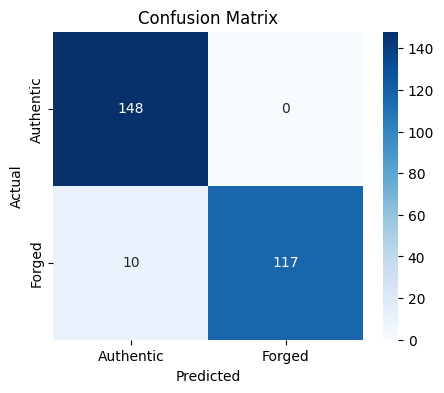

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Authentic", "Forged"],
    yticklabels=["Authentic", "Forged"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

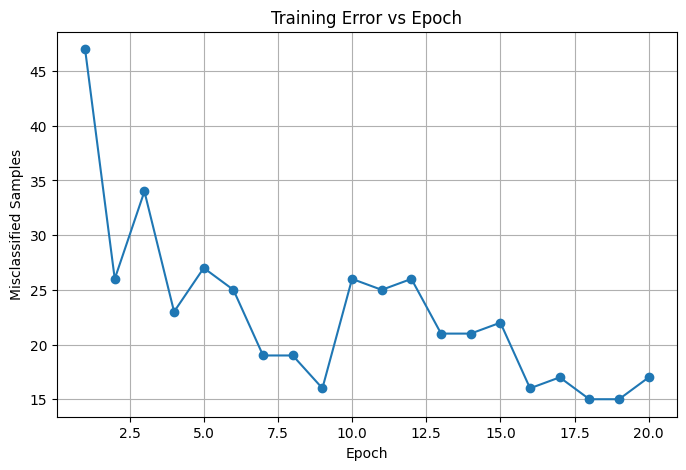

In [84]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), errors_history, marker='o')
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)
plt.show()

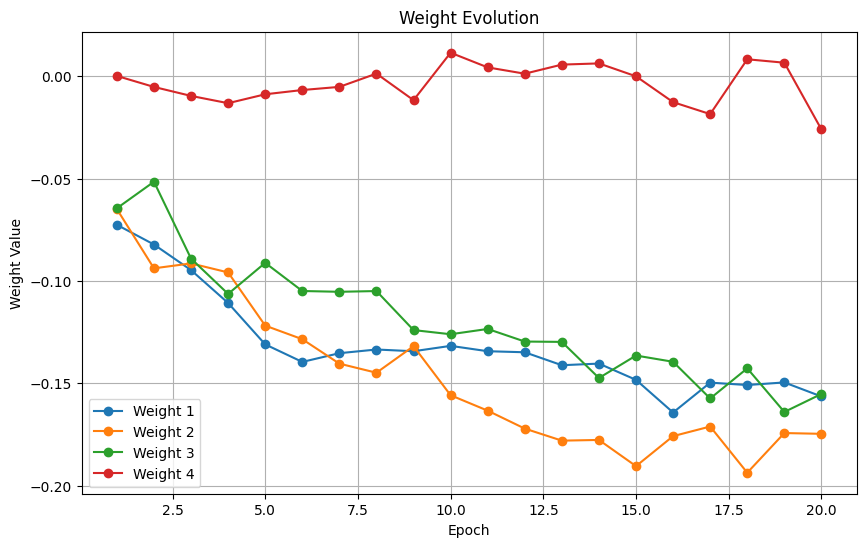

In [85]:
weights_history = np.array(weights_history)
plt.figure(figsize=(10,6))
for i in range(weights_history.shape[1]):
    plt.plot(
        range(1, epochs+1),
        weights_history[:, i],
        marker='o',
        label=f"Weight {i+1}"
    )
plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.show()

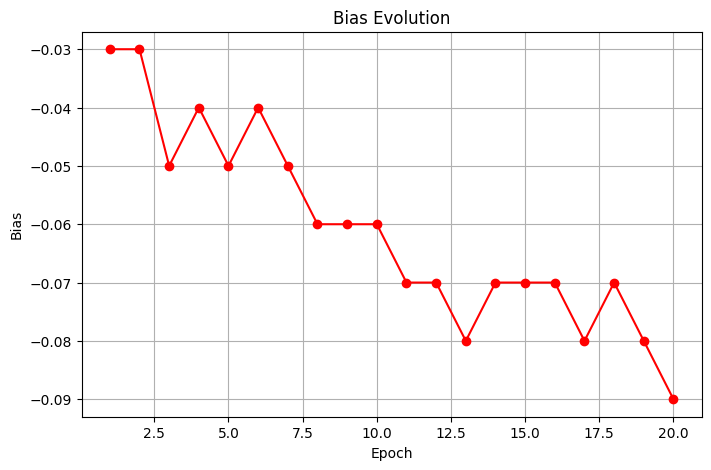

In [86]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1, epochs+1),
    bias_history,
    marker='o',
    color='red'
)
plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.grid(True)
plt.show()

In [87]:
def train_perceptron(lr):
    weights = np.zeros(X_train.shape[1])
    bias = 0
    errors = []
    for epoch in range(20):
        epoch_error = 0
        for i in range(len(X_train)):
            z = np.dot(X_train[i], weights) + bias
            prediction = 1 if z >= 0 else 0
            error = y_train.iloc[i] - prediction
            if error != 0:
                weights += lr * error * X_train[i]
                bias += lr * error
                epoch_error += 1
        errors.append(epoch_error)
    return errors

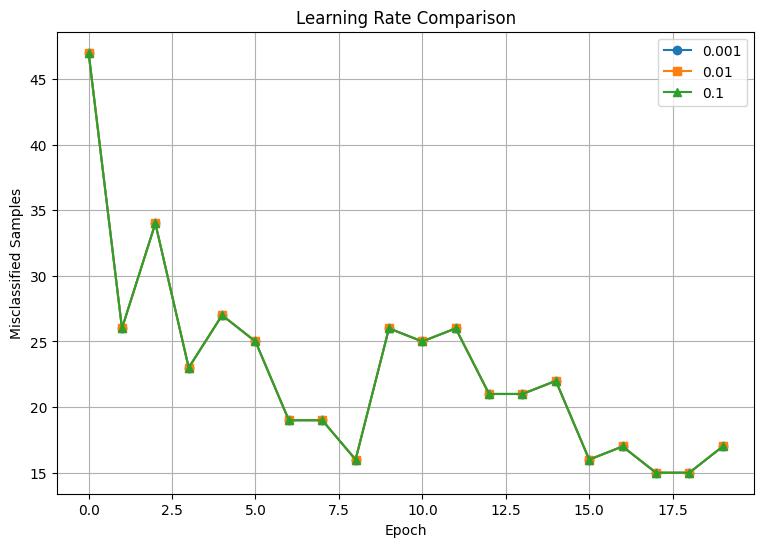

In [88]:
errors1 = train_perceptron(0.001)
errors2 = train_perceptron(0.01)
errors3 = train_perceptron(0.1)
plt.figure(figsize=(9,6))
plt.plot(errors1, marker='o', label='0.001')
plt.plot(errors2, marker='s', label='0.01')
plt.plot(errors3, marker='^', label='0.1')
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
summary = {
    "Metric": [
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        len(df),
        "80% / 20%",
        learning_rate,
        epochs,
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4)
    ]
}
summary_df = pd.DataFrame(summary)
summary_df

,Metric,Value
0,Dataset Size,1372
1,Train/Test Split,80% / 20%
2,Learning Rate,0.01
3,Epochs,20
4,Accuracy,0.9636
5,Precision,1.0
6,Recall,0.9213
7,F1 Score,0.959
